In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# Linear regression
# plot a curve between Ave Rooms and Med House val

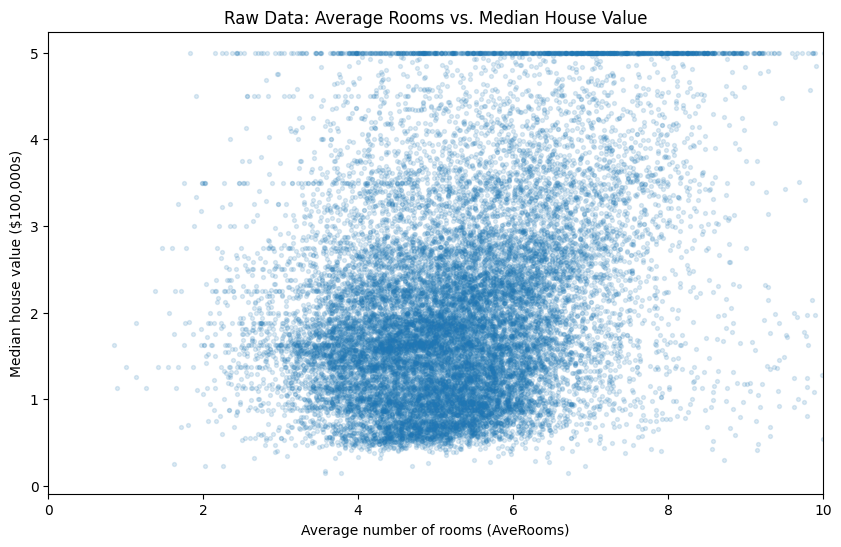

In [6]:
# Raw relationship between average rooms and median house value
x = df['AveRooms'].to_numpy()
y = df['MedHouseVal'].to_numpy()

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=8, alpha=0.15)
plt.xlabel('Average number of rooms (AveRooms)')
plt.xlim(0, 10)
plt.ylabel('Median house value ($100,000s)')
plt.title('Raw Data: Average Rooms vs. Median House Value')
plt.show()

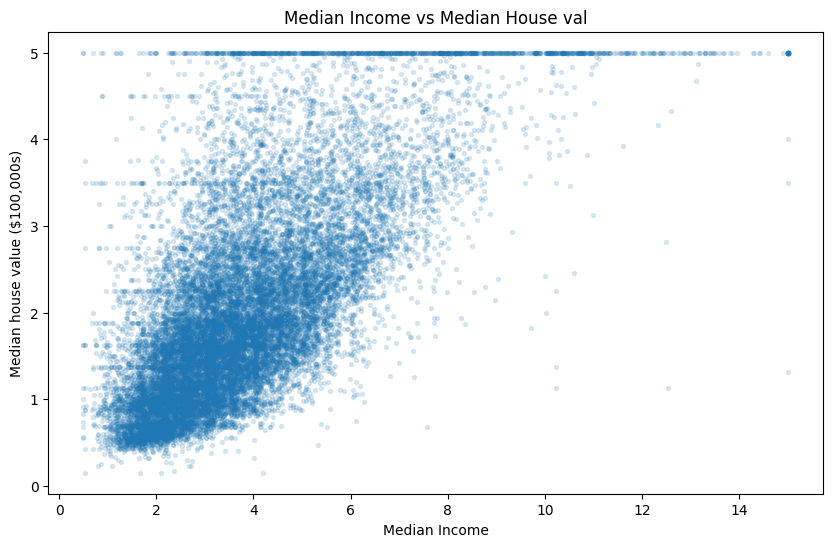

In [7]:
x = df["MedInc"].to_numpy()
y = df["MedHouseVal"].to_numpy()

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=8, alpha=0.15)
plt.xlabel("Median Income")
plt.ylabel("Median house value ($100,000s)")
plt.title("Median Income vs Median House val")
plt.show()

#### When feature scaling is needed

The input features have very different ranges: `Population` can be in the thousands, while `MedInc` is much smaller. Standardization puts every feature on a comparable scale.

For this notebook's plain `LinearRegression()` model, scaling is **not required**: ordinary least squares finds the same best-fitting predictions with or without it, apart from tiny numerical differences. Scaling changes the units of the learned coefficients.

Scaling is **needed or strongly recommended** when using:

- Gradient Descent or SGD, because similarly scaled features make optimization more stable and faster.
- Ridge or Lasso Regression, because regularization penalizes coefficients fairly only when features have comparable scales.
- Scale-sensitive models such as KNN, SVM, and neural networks.


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


# Input data
x, y = housing.data, housing.target
# x[0:5], y[0:5]
# x.info()
# y[:5]

# train/test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# scaling the train_data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train
model = LinearRegression()
# model.fit(x_train, y_train)
model.fit(x_train_scaled, y_train)

# predict
y_pred = model.predict(x_test_scaled)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

# Inspect learned coefficients
print(f"\nFeature coefficients: ")
for name, coef in zip(housing.feature_names, model.coef_):
    print(f" {name}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

MSE: 0.5559
RMSE: 0.7456
MAE: 0.5332
R2: 0.5758

Feature coefficients: 
 MedInc: 0.8544
 HouseAge: 0.1225
 AveRooms: -0.2944
 AveBedrms: 0.3393
 Population: -0.0023
 AveOccup: -0.0408
 Latitude: -0.8969
 Longitude: -0.8698
Intercept: 2.0719


## Linear Regression: model, training objective, and evaluation

Let $X \in \mathbb{R}^{n \times d}$ be the feature matrix: $n$ California districts and $d=8$ input features. Let $y \in \mathbb{R}^{n}$ be the true median house values.

### Formula notation

- $X$: the complete feature matrix containing all input values.
- $\in$: “belongs to” or “is an element of.”
- $\mathbb{R}$: the set of real numbers.
- $X \in \mathbb{R}^{n \times d}$: $X$ is a real-valued matrix with $n$ rows and $d$ columns. Each row is one district; each column is one feature.
- $n$: number of training examples.
- $m$: number of test examples.
- $d$: number of input features.
- $\mathbf{x}_i$: feature values for example $i$.
- $x_j$: value of feature $j$, such as `MedInc`, for one example.
- $y_i$: actual median house value for example $i$.
- $\hat{y}_i$: model prediction for example $i$.
- $\bar{y}$: mean of the true test-set values.
- $\beta_j$: learned coefficient for feature $j$; $\beta_0$ is the learned intercept.

### Model

For one district with features $\mathbf{x}$, Linear Regression predicts:

$$\hat{y} = \beta_0 + \sum_{j=1}^{d} \beta_j x_j = \mathbf{x}^{T}\boldsymbol{\beta} + \beta_0$$

- $\hat{y}$ is the predicted median house value.
- $\beta_0$ is the intercept (`model.intercept_`).
- $\beta_j$ is the coefficient for feature $x_j$ (`model.coef_`).

This formula is used because it gives each feature a learnable linear contribution to the prediction. For example, holding the other features fixed, a positive `MedInc` coefficient means a larger median income increases the predicted house value.

### Training objective: Ordinary Least Squares

The model chooses $\boldsymbol{\beta}$ and $\beta_0$ to minimize Mean Squared Error on the training set:

$$J(\boldsymbol{\beta}, \beta_0) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Squaring makes positive and negative errors count equally, penalizes large errors more strongly, and gives a smooth objective that can be optimized efficiently. `LinearRegression().fit(...)` finds the coefficients that minimize this objective.

### Feature scaling: standardization

`StandardScaler` transforms each feature $j$ using the training-set mean and standard deviation:

$$x_{ij}^{\mathrm{scaled}} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

$$\mu_j = \frac{1}{n}\sum_{i=1}^{n}x_{ij}, \qquad \sigma_j = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_{ij}-\mu_j)^2}$$

- $x_{ij}$ is feature $j$ for example $i$.
- $\mu_j$ and $\sigma_j$ are calculated from `x_train` only with `scaler.fit_transform(x_train)`.
- The same learned $\mu_j$ and $\sigma_j$ are applied to `x_test` with `scaler.transform(x_test)`. This prevents test-data leakage.

Standardization puts features with very different ranges, such as `Population` and `MedInc`, on a comparable scale. It makes coefficients easier to compare and is important for gradient-based models. For ordinary least squares Linear Regression, it should leave predictions and evaluation metrics essentially unchanged; it changes the coefficient units instead.

### Test-set evaluation

The held-out test set is not used to fit the coefficients. It estimates how well the model predicts unseen districts.

$$\mathrm{MSE} = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$

$$\mathrm{RMSE} = \sqrt{\mathrm{MSE}}$$

$$\mathrm{MAE} = \frac{1}{m} \sum_{i=1}^{m} |y_i - \hat{y}_i|$$

$$R^2 = 1 - \frac{\sum_{i=1}^{m}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{m}(y_i - \bar{y})^2}$$

### Which direction is better?

- **MSE** is the same squared-error objective used for training. **Minimize it:** $0$ is a perfect score (best), smaller is better, and there is no fixed worst value. Large errors have a large effect because they are squared.
- **RMSE** converts MSE back to the target's unit, making typical error easier to interpret. **Minimize it:** $0$ is best and there is no fixed worst value. Here its unit is hundreds of thousands of US dollars because `MedHouseVal` uses that unit.
- **MAE** gives the average absolute prediction error and is less affected by large errors than MSE. **Minimize it:** $0$ is best and there is no fixed worst value. It is also measured in hundreds of thousands of US dollars here.
- **$R^2$** compares the model against predicting the test-set mean $\bar{y}$ for every district. **Maximize it:** $1$ is perfect, $0$ matches the mean baseline, and a negative score is worse than that baseline. Its best value is $1$, but it can become arbitrarily negative.


In [ ]:
# Now numpy implementation